# Entropic Regularization of Optimal Transport [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xavimaass/computational_optimal_transport_2026/blob/main/assignments/HW4.ipynb)

**Student Name:** Anthony Matar

In this notebook, we will explore the regularized OT problem.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

We consider two input histograms $a, b \in \Sigma_n$, where the probability simplex in $\mathbb{R}^n$ is defined as
$$
\Sigma_n := \left\{ a \in \mathbb{R}_+^n \;\middle|\; \sum_{i=1}^n a_i = 1 \right\}.
$$

We define the discrete entropic regularized transport cost as
$$
W_\epsilon(a, b) := \min_{P \in U(a, b)} \sum_{i,j} C_{i,j} P_{i,j} - \epsilon E(P),
$$
where the polytope of couplings is given by
$$
U(a, b) := \left\{ P \in \left(\mathbb{R}_+\right)^{n \times m} \;\middle|\; P \mathbf{1}_m = a,\; P^\top \mathbf{1}_n = b \right\},
$$
with $\mathbf{1}_n := (1, \ldots, 1)^\top \in \mathbb{R}^n$.

For $P \in \mathbb{R}_+^{n \times m}$, the entropy is defined as
$$
E(P) := -\sum_{i,j} P_{i,j} \left( \log(P_{i,j}) - 1 \right).
$$

When $\epsilon = 0$, one recovers the classical (discrete) optimal transport cost.

Remark that here we do not use the product measure as a reference but the uniform measure. By a remark discussed in class this does not change the minimizers of the problem however you may have to adapt certain formulas from the class to this different choice of reference measure.

The matrix $C \in \left(\mathbb{R}_+\right)^{n \times m}$ defines the ground cost, where $C_{i,j}$ is the cost of transporting mass from bin $i$ to bin $j$.

The regularized transport problem can be rewritten as a projection:
$$
W_\epsilon(a, b) = \epsilon \min_{P \in U(a, b)} \mathrm{KL}(P \,\|\, K),
$$
where the Gibbs kernel $K$ is defined as
$$
K_{i,j} := \exp\left( -\frac{C_{i,j}}{\epsilon} \right),
$$
and the Kullback-Leibler divergence between $P, K \in \mathbb{R}_+^{n \times m}$ is given by
$$
\mathrm{KL}(P \,\|\, K) := \sum_{i,j} P_{i,j} \left( \log\left( \frac{P_{i,j}}{K_{i,j}} \right) - 1 \right).
$$

Given a convex set $S \subset \mathbb{R}^N$, the projection of $\xi$ onto $S$ with respect to the Kullback-Leibler divergence is defined as
$$
\mathrm{Proj}_{S}^{\mathrm{KL}}(\xi) := \underset{\pi \in S}{\arg\min} \, \mathrm{KL}(\pi \,\|\, \xi).
$$

## Sinkhorn's Algorithm

A fundamental observation is that the optimality condition of the entropic regularized transport problem implies that the optimal coupling $P_\epsilon$ necessarily has the form
$$
P_\epsilon = \operatorname{diag}(u) \, K \, \operatorname{diag}(v),
$$
where the Gibbs kernel is defined as
$$
K := \exp\left( -\frac{C}{\epsilon} \right).
$$

To satisfy the marginal constraints, one must find two positive scaling vectors $u \in \mathbb{R}_+^n$ and $v \in \mathbb{R}_+^m$ such that the following equalities hold:
$$
P \mathbf{1}_m = u \odot (K v) = a, \quad \text{and} \quad
P^\top \mathbf{1}_n = v \odot (K^\top u) = b,
$$
where $\odot$ denotes element-wise (Hadamard) multiplication.

Sinkhorn's algorithm alternates between updates of these two equations and proceeds as follows:
$$
u \leftarrow \frac{a}{K v}, \quad
v \leftarrow \frac{b}{K^\top u},
$$
where the divisions are element-wise.

The algorithm is typically initialized with
$$
v = \mathbf{1}_m,
$$
where $\mathbf{1}_m$ is the vector of all ones in $\mathbb{R}^m$.  
The vector $u$ does not need to be explicitly initialized, as it is computed in the first iteration.

## Transport Between Point Clouds
We first test the method for two input measures that are uniform measures (i.e. constant histograms) supported on two point clouds (that do not necessarily have the same size).


We thus first load two points clouds $x=(x_i)_{i=1}^{n}, y=(y_i)_{i=1}^{m}, $ where $x_i, y_i \in \mathbb{R}^2$.


Number of points in each cloud, $N=(n,m)$.

In [34]:
N = [300,200] # Number of Points
d = 2 # point cloud dimension

**Exercise 1.**

Complete the code to generate the two point clouds x and y as follows:
- x: N[0] points drawn uniformly in the square $[-0.5, 0.5]\times [-0.5, 0.5]$
- y: N[1] points drawn uniformly on an annulus of inner radius 0.8 and outer radius 1.0 (_Hint: sample $\theta \in [0, 2\pi]$ and $r \in [0.8, 1.0]$ uniformly_)

Also, complete the code for computing the Cost matrix:
$$
C_{i,j} = \|x_i - y_j\|^2,
$$
where $\|\cdot\|$ denotes the Euclidean norm in $\mathbb{R}^d$.


In [35]:
def generate_data(N):
  """
  Generate two point clouds x and y.
  Returns:
    x: np.array of shape (2, N[0])
    y: np.array of shape (2, N[1])
    """
  x = np.random.uniform(-0.5, 0.5, size=(2, N[0]))

  # y: uniform on annulus with inner radius 0.8, outer radius 1.0
  theta = np.random.uniform(0, 2 * np.pi, N[1])
  r = np.random.uniform(0.8, 1.0, N[1])
  y = np.array([r * np.cos(theta), r * np.sin(theta)])
  return x, y


In [36]:
def compute_cost_matrix(x, y):
  """
  Compute the cost matrix C.
  Returns:
  C: np.array of shape (N[0], N[1])
  """
  C = np.sum((x[:, :, np.newaxis] - y[:, np.newaxis, :]) ** 2, axis=0)
  return C

We now generate the dataset using the functions you completed.

In [37]:
x, y = generate_data(N)
C = compute_cost_matrix(x, y)

We provide the following function for displaying the point clouds.

In [38]:
def plot_point_cloud_and_transport(x, y, P = None):
  """
  Plot two point clouds and (if given) the associated transport plan.
  Arguments:
  - x: np.array of shape (2, N[0])
  - y: np.array of shape (2, N[1])
  - P: np.array of shape (N[0], N[1]) or None. Must be stochastic matrix representing transport valid plan.
  """
  plt.figure(figsize=(10,10))

  plt.scatter(x[0,:], x[1,:], s=200, edgecolors="k", c='b', linewidths=2)
  plt.scatter(y[0,:], y[1,:], s=200, edgecolors="k", c='r', linewidths=2)

  if P is not None:
    A = P * (P > np.max(P)*.8)
    i,j = np.where(A != 0)
    plt.plot([x[0,i],y[0,j]],[x[1,i],y[1,j]],'k',lw = 2)

    A = P * (P > np.max(P)*.2)
    i,j = np.where(A != 0)
    plt.plot([x[0,i],y[0,j]],[x[1,i],y[1,j]],'k:',lw = 1)

  plt.axis("off")
  plt.xlim(np.min(y[0,:])-.1,np.max(y[0,:])+.1)
  plt.ylim(np.min(y[1,:])-.1,np.max(y[1,:])+.1)

  plt.show()

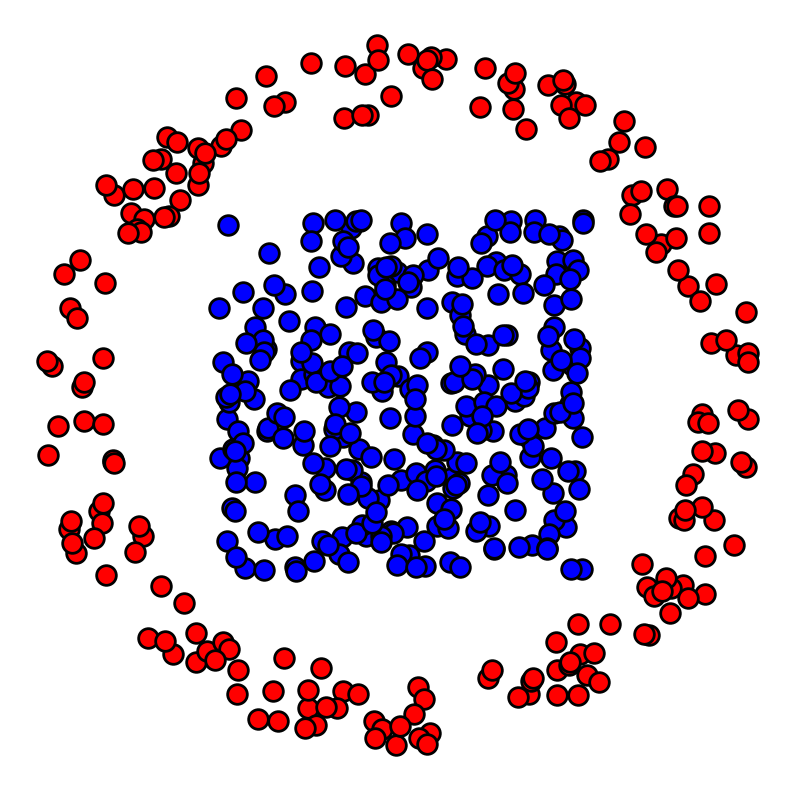

In [39]:
plot_point_cloud_and_transport(x,y)

We assign equal weight  $(a,b)$ to all points on each point cloud (i.e. uniform histograms).

In [40]:
a = np.ones(N[0])/N[0]
b = np.ones(N[1])/N[1]

**Exercise 2.** Complete the function to compute the Gibbs Kernel

In [41]:
def gibbs_kernel(C, epsilon):
  """
  Returns the Gibbs kernel K as defined above.
  K: np.array of shape (N[0], N[1])
  """
  K = np.exp(-C/epsilon)
  return K

We now generate a Gibbs Kernel $K$ with regularization strength $\epsilon>0$.

In [42]:
epsilon = .01
K = gibbs_kernel(C, epsilon)

**Exercise 3.** Implement the Sinkhorn Algorithm by completing the following function.

To monitor convergence, you need to track the evolution of the "constraint satisfaction errors":
$$
\|P \mathbf{1}_m - a\|_1 \quad \text{and} \quad \|P^\top \mathbf{1}_n - b\|_1,
$$
where  $P = \operatorname{diag}(u) K \operatorname{diag}(v)$.  Note that these residuals can be computed directly from the scaling vectors $(u, v)$ as:
$$
P \mathbf{1}_m = u \odot (K v), \quad
P^\top \mathbf{1}_n = v \odot (K^\top u).
$$

Recall that $Ax$ in numpy corresponds to `A @ x`, whereas $a \odot b$ is `a*b`

In [43]:
def sinkhorn(a, b, K, niter=1000):
    """
    Run Sinkhorn's algorithm.
    Returns scaling vectors u (of shape (len(a),)), v (of shape (len(b),)) 
    and convergence errors Err_p (list of |P 1_m - a|_1), Err_q (list of |P^T 1_n - b|_1).
    """
    v = np.ones(len(b))
    Err_p, Err_q = [], []
    for i in tqdm(range(niter)):
        u = a / (K @ v)
        v = b / (K.T @ u)
        Err_p.append(np.sum(np.abs(u * (K @ v) - a)))

        
        Err_q.append(np.sum(np.abs(v * (K.T @ u) - b)))
    return u, v, Err_p, Err_q

In [44]:
epsilon = 0.01
K = gibbs_kernel(C, epsilon)

u,v, Err_p, Err_q = sinkhorn(a, b, K, niter=5000)

100%|██████████| 5000/5000 [00:00<00:00, 16997.61it/s]


In [45]:
def plot_marginal_errors(err_p, err_q, eps=1e-16):
    """
    Plot log-marginal errors for P1-a and P^T1-b.
    err_p : array-like with errors for ||P 1 - a||.
    err_q : array-like with errors for ||P^T 1 - b||.
    eps (optional) : small value to avoid log(0).
    """
    err_p = np.asarray(err_p)
    err_q = np.asarray(err_q)

    fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    ax[0].plot(np.log(err_p + eps), linewidth=2)
    ax[0].set_title(r"$\|P \mathbf{1} - a\|$")
    ax[0].set_ylabel("Log Error")
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(np.log(err_q + eps), linewidth=2)
    ax[1].set_title(r"$\|P^\top \mathbf{1} - b\|$")
    ax[1].set_xlabel("Iterations")
    ax[1].set_ylabel("Log Error")
    ax[1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

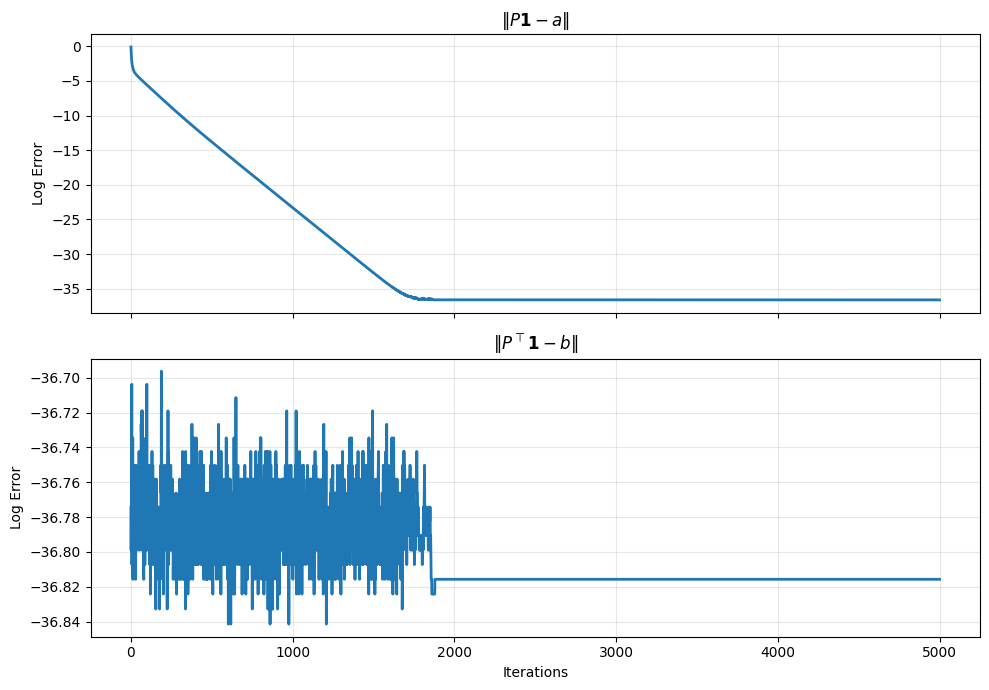

In [46]:
# We plot the errors of the marginals in a log scale to better visualize convergence.
plot_marginal_errors(Err_p, Err_q)

**Exercise 4.** Implement the function to compute the optimal transport plan from u, v and K.
$P = \operatorname{diag}(u) K \operatorname{diag}(v)$
Then display it and comment on the obtained results.

In [47]:
def transport_coupling(u, v, K):
  """Returns the optimal coupling P given by diag(u) K diag(v)"""
  
  P = np.diag(u) @ K @ np.diag(v)
  return P

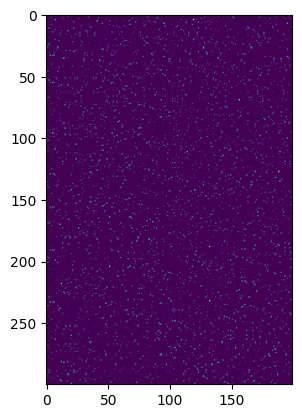

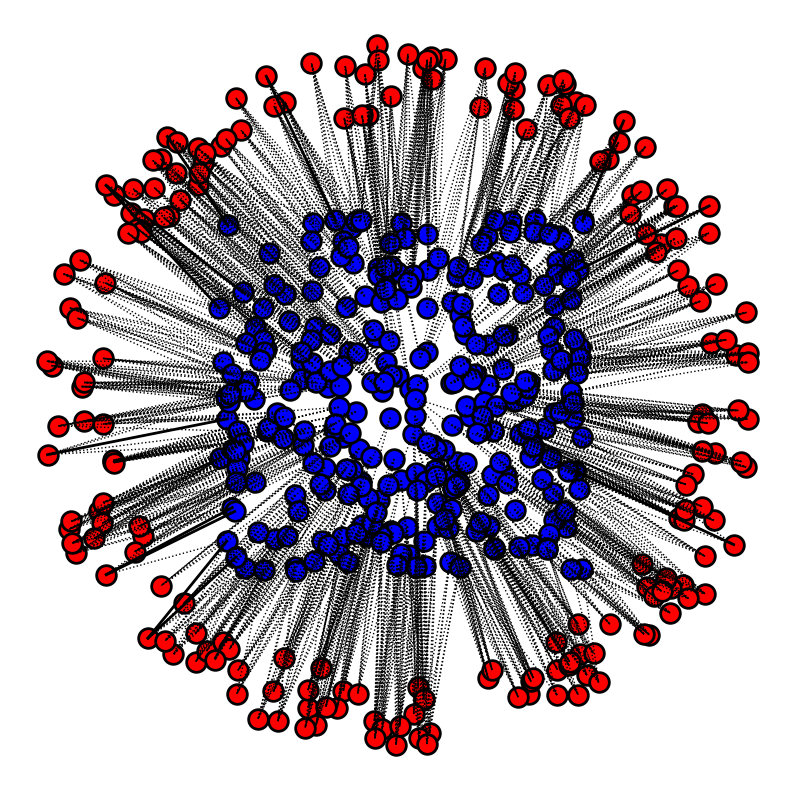

In [48]:
# We compute it and display it.
P = transport_coupling(u, v, K)
plt.imshow(P)
plot_point_cloud_and_transport(x,y,P)

The imshow(P) heatmap shows a sparse, structured matrix — most entries are near zero with only a few bright spots per row/column. This is expected: with ε = 0.01 (small regularization), the plan is close to the unregularized OT solution, so each source point concentrates its mass on a small number of target points rather than spreading uniformly.

In the point cloud plot:

Blue points (source, uniform square) are transported to red points (target, annulus).
The transport lines are roughly radial — each square point maps preferentially to the nearest arc of the annulus, since the cost is squared Euclidean distance.
Points near the corners of the square map to the nearby quadrant of the annulus (shortest path outward).
Points near the center of the square are roughly equidistant from all parts of the annulus, so their transport is more spread out — visible as multiple dashed lines (lower-weight connections) from central source points.
The solid lines (weight > 80% of max) highlight the dominant transport directions; the dashed lines (weight > 20% of max) reveal the entropic blur, i.e. the small amount of mass spread to nearby target points due to the regularization ε > 0.
As ε → 0, we would expect the plan to concentrate further and the dashed lines to disappear, recovering the deterministic OT map.


## Testing multiple values of $\epsilon$.

As $\epsilon$ decreases, we expect the solution to become increasingly sparse and to concentrate around the minimal-cost entries.

**Exercise 5.** Complete the following function `compute_transport_plans` to compute the optimal transport plans for a given list of values for ɛ. Then, use the function `plot_transport_plans` to visualize them and comment on the results.

In [49]:
def compute_transport_plans(C, a, b, epsilon_list, niter=300):
    """
    Returns a list of transport plans corresponding to different values of regularization.
    """
    plans = []
    # COMPLEte
    for eps in epsilon_list: 
        
        K = gibbs_kernel(C, eps)
        u, v, _, _ = sinkhorn(a, b, K, niter=niter)
        P = transport_coupling(u, v, K)
        plans.append(P)
    return plans

In [50]:
def plot_transport_plans(plans, epsilon_list, N):
    """
    Plot a list of transport plans.
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    vmax = 0.3 * np.min(1 / np.asarray(N))

    for ax, P, eps in zip(axes.ravel(), plans, epsilon_list):
        # Clamp P values for visualization and display with imshow
        ax.imshow(np.clip(P, 0, vmax))
        ax.set_title(rf"$\varepsilon = {eps:.3f}$")
        ax.axis("off")

    fig.tight_layout()
    plt.show()


100%|██████████| 300/300 [00:00<00:00, 16972.06it/s]


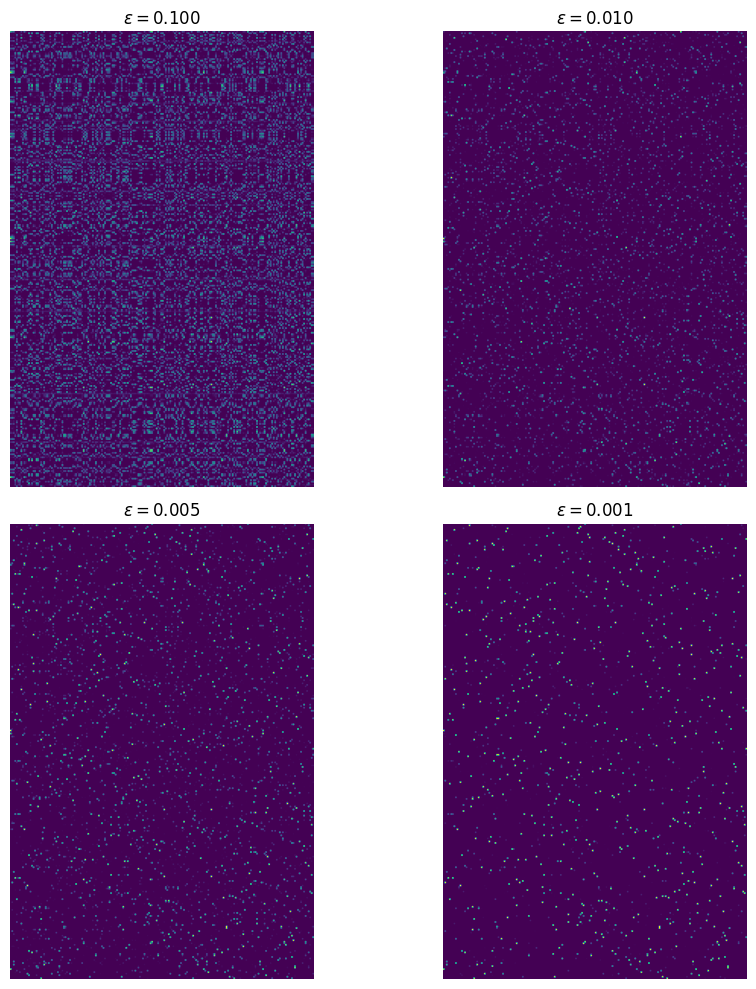

In [51]:
epsilon_list = [0.1, 0.01, 0.005, 0.001]
niter = 300
plans = compute_transport_plans(C, a, b, epsilon_list, niter=niter)
plot_transport_plans(plans, epsilon_list, N)

As ε decreases across [0.1, 0.01, 0.005, 0.001]:

ε = 0.1 (large): P is very diffuse — mass is spread nearly uniformly across the matrix. The entropic penalty dominates, pushing the plan toward the product measure ab^T. The imshow appears almost flat.

ε = 0.01: The plan becomes noticeably sparser. Bright bands emerge corresponding to geometrically close source-target pairs (nearest points on the annulus to each square point).

ε = 0.005: Further concentration. The structure sharpens — the plan resembles a near-deterministic assignment, with most mass concentrated along a low-cost "path" through the matrix.

ε = 0.001 (small): The plan is highly concentrated, approaching the unregularized OT solution. Only a handful of entries per row/column are non-negligible. The bright spots are tight and well-separated.

Key takeaway: Smaller ε trades off smoothness for accuracy — the transport plan better approximates true OT but Sinkhorn may require more iterations to converge (and can suffer numerical underflow as K = exp(-C/ε) entries approach zero).

## Transport Between Histograms
We now consider a different setup, where the histogram values $a,b$ are not uniform, but the measures are defined on a uniform grid $x_i=y_i=i/n$. They are thue often refered to as "histograms".

We fix a common number of points `N=200`, and define a variable `t` which will represent the `N` points in this grid.

In [52]:
N = 200
t = np.arange(0,N)/N

**Exercise 6.**

Define two probability histograms `a` and `b` on the grid `t` as follows:
- complete the function `gaussian_density` for it to calculate: $f(t; t_0, \sigma) =\ exp\big(\frac{-(t-t_0)^2}{2\sigma^2}\big)$
- Fix `sigma = 0.06`, and define: `a = gaussian_density(t, 0.25, sigma)` and `b = gaussian_density(t, 0.8, sigma)`.
- To ensure strict positivity, add a small `min_mass = 0.008` to `a` and `b` and then use `normalize` to turn them back into probability distributions.
Why do we need to have strictly positive mass for Sinkhorn's algorithm to be well-defined?

In [53]:
def normalize(p):
  return p/np.sum(p)

def gaussian_density(t, t0, sigma):
  """Returns a gaussian density on the grid t
  Inputs:
  t: np.array of shape (N,)
  t0: float
  sigma: float
  Returns a np.array of shape (N,)
  """
  
  return np.exp(-((t - t0) ** 2) / (2 * sigma ** 2))



sigma = 0.06
min_mass = 0.008

a = normalize(gaussian_density(t, 0.25, sigma) + min_mass)
b = normalize(gaussian_density(t, 0.8, sigma) + min_mass)

Why strict positivity is needed:

Sinkhorn alternates u = a / (K @ v) and v = b / (K.T @ u). If any entry a_i = 0, then u_i = 0, which zeroes out the entire i-th row of P = diag(u) K diag(v). That row then contributes zero mass regardless of v, meaning the marginal constraint P 1 = a is trivially satisfied there — but the algorithm can no longer adjust that row to satisfy the other marginal. More concretely, a zero in a or b causes division by zero in the scaling updates, making the iterates undefined. Adding min_mass = 0.008 ensures every bin has strictly positive weight, keeping all divisions well-defined throughout.

We display the histograms you generated.

In [54]:
def plot_histograms(t, a, b):
  plt.figure(figsize = (10,7))
  plt.subplot(2, 1, 1)
  plt.bar(t, a, width = 1/len(t), color = "darkblue")
  plt.subplot(2, 1, 2)
  plt.bar(t, b, width = 1/len(t), color = "darkblue")
  plt.show()

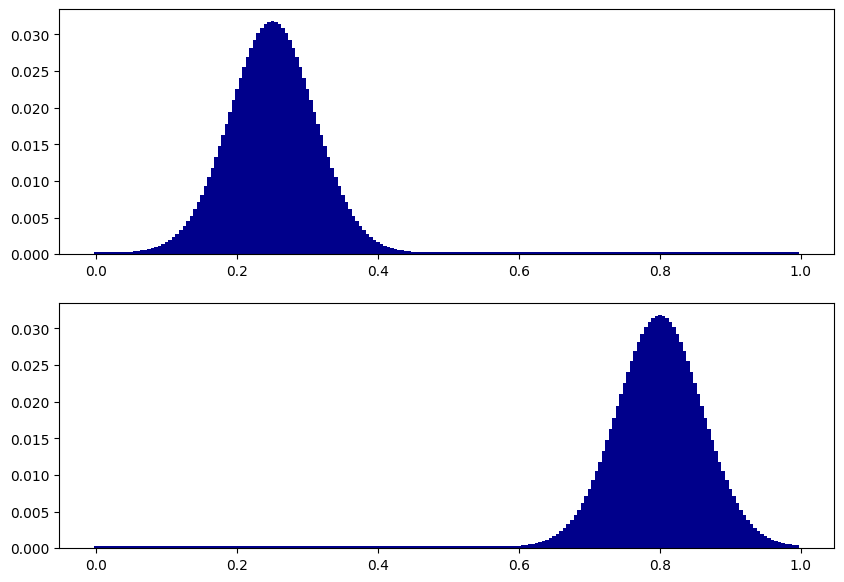

In [55]:
plot_histograms(t, a, b)

We now compute the cost matrix and the Gibbs Kernel.

In [56]:
C = compute_cost_matrix(t[np.newaxis, :],t[np.newaxis,:])
epsilon = (.03)**2
K = gibbs_kernel(C, epsilon)

**Exercise 7.** Use the Sinkhorn algorithm to find the optimal transport plan. Plot the marginal errors. Compute the transport map P. Use the function `plot_transport_map` to plot it.

In [57]:
def plot_transport_map(P, s=None, t=None, title="Transport Plan"):
  plt.figure(figsize=(5, 5))
  plt.imshow(np.log(P + 1e-5))
  if s is not None and t is not None:
    plt.plot(s * N, t * N, 'r', linewidth=3)
  plt.title(title)
  plt.axis('off')
  plt.show()

100%|██████████| 5000/5000 [00:00<00:00, 23293.72it/s]


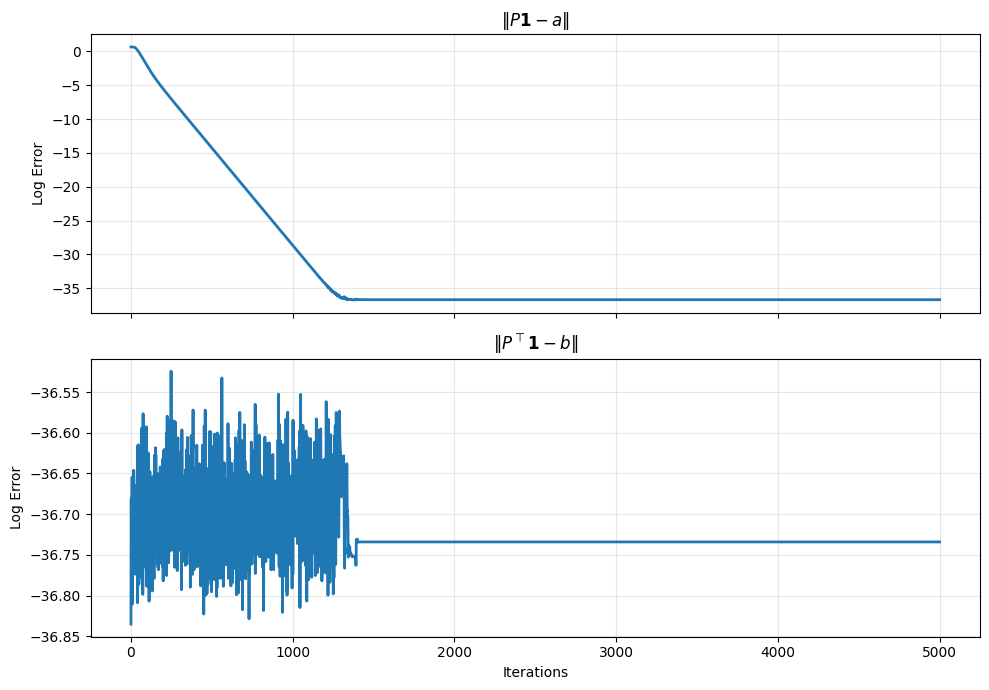

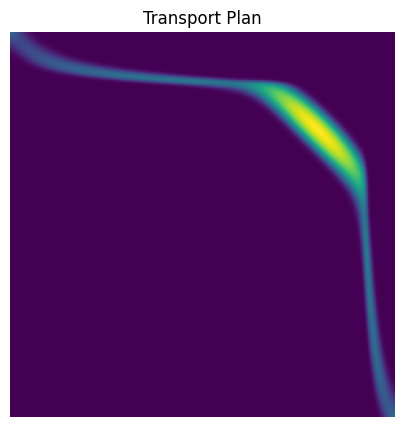

In [63]:
# Run Sinkhorn
u, v, Err_p, Err_q = sinkhorn(a, b, K, niter=5000)

# Plot marginal errors
plot_marginal_errors(Err_p, Err_q)

# Compute transport plan
P = transport_coupling(u, v, K)

# Plot transport map
plot_transport_map(P)

One can approximate the transport map between the two measures using the so-called **barycentric projection**. For each source point indexed by $i$, this projection is defined as:
$$
s_i := \frac{\sum_{j} P_{i,j} \, t_j}{\sum_{j} P_{i,j}}
= \frac{\left[ u \odot \left( K (v \odot t) \right) \right]_i}{a_i},
$$
where:
- $t_j \in [0,1]$ is the target value associated with index $j$,
- $\odot$ denotes element-wise (Hadamard) multiplication,
- $\frac{\cdot}{\cdot}$ denotes element-wise division.

This computation avoids explicitly constructing the full transport matrix $P$ and instead relies on efficient kernel-vector operations involving $K$, $u$, and $v$.

**Exercise 8.** Complete the following function to compute the Barycentric projection.

In [59]:
def barycentric_projection(u, v, K, t, a):
    """
    Compute the barycentric projection as indicated above.
    Returns an array s of shape (N,) representing the barycentric projection
    """
  
    s = (u * (K @ (v * t))) / a
    return s

In [60]:
s = barycentric_projection(u, v, K, t, a)

We display the transport map, super-imposed over the coupling.

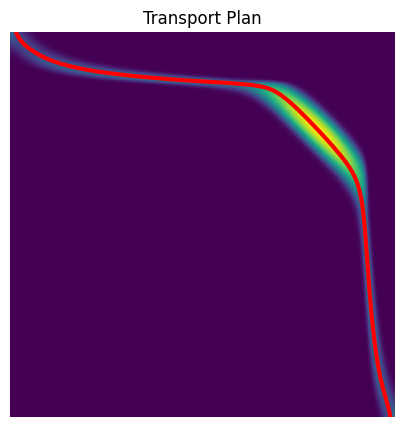

In [61]:
plot_transport_map(P, s, t)

**Exercise 9.** Use the functions from the previous parts to explore the effect of varying the regularization strength $\epsilon$ on the barycentric projection and the resulting transport plan.

Try computing and visualizing the transport map for different values of $\epsilon$. 
Namely, iterate over `epsilon_values`:
1. Recompute the Gibbs Kernel `K_eps` for the specific epsilon.
2. Run Sinkhorn to get scaling vectors `u_eps` and `v_eps`.
3. Compute the coupling `P_eps` for visualization.
4. Compute the barycentric projection `s_eps`.
5. Plot the result for each value of epsilon: `plot_transport_map(P_eps, s_eps, t, title=r"Transport Map ($\varepsilon = $"+f"{epsilon_values[i]})")`

Comment on your results. You should expect that:
- Larger $\epsilon$ produces smoother, more diffused transport plans.
- Smaller $\epsilon$ results in more sharply concentrated transport, approximating the unregularized optimal transport solution.

100%|██████████| 2000/2000 [00:00<00:00, 25055.73it/s]


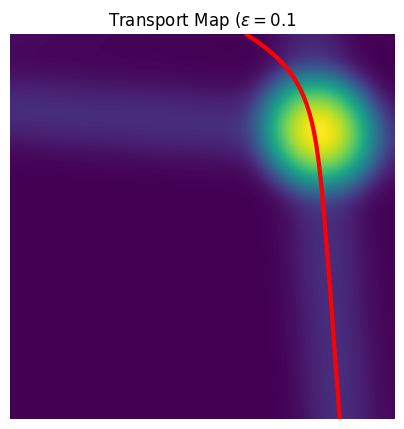

100%|██████████| 2000/2000 [00:00<00:00, 24680.43it/s]


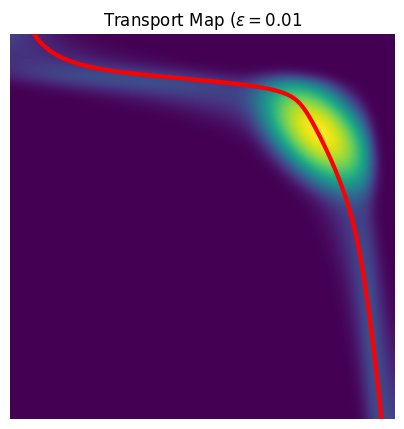

100%|██████████| 2000/2000 [00:00<00:00, 25746.62it/s]


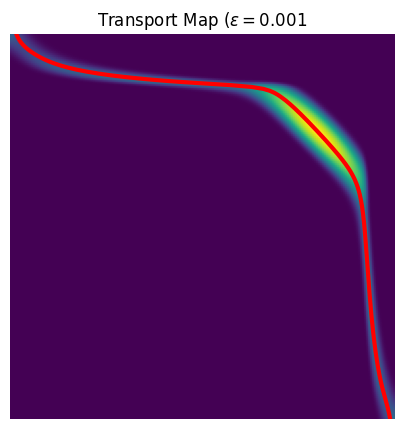

100%|██████████| 2000/2000 [00:00<00:00, 25027.85it/s]


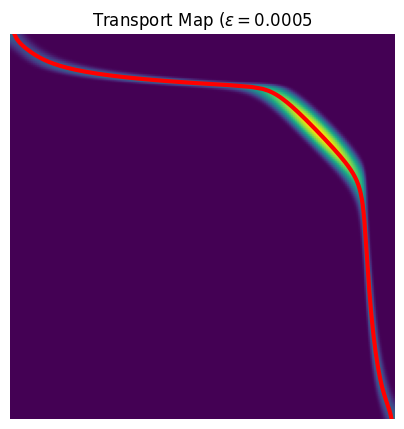

In [62]:
epsilon_values = [0.1, 0.01, 0.001, 0.0005]
niter = 2000

for i, eps in enumerate(epsilon_values):
    K_eps = gibbs_kernel(C, eps)
    u_eps, v_eps, _, _ = sinkhorn(a, b, K_eps, niter=niter)
    P_eps = transport_coupling(u_eps, v_eps, K_eps)
    s_eps = barycentric_projection(u_eps, v_eps, K_eps, t, a)
    plot_transport_map(P_eps, s_eps, t, title=r"Transport Map ($\varepsilon = $" + f"{epsilon_values[i]}")


Comment on results:

ε = 0.1 (large): The coupling is very diffuse — the log-heatmap shows a wide blurred band. The barycentric projection (red line) is a smoothed, over-regularized approximation of the true map and doesn't sharply follow the diagonal shift. Mass is spread across many target bins.

ε = 0.01: The band narrows significantly. The red line starts tracking a cleaner near-linear shift from t₀ = 0.25 to t₀ = 0.8, but still has some entropic blur around it.

ε = 0.001: The transport plan is tightly concentrated. The log-heatmap shows a thin bright diagonal band. The barycentric projection closely approximates the true OT map — a near-perfect translation t → t + 0.55.

ε = 0.0005 (very small): The plan is maximally sharp. The coupling nearly degenerates to a deterministic map. The red line lies almost exactly along the optimal transport diagonal. However, numerical issues may arise here (entries of K = exp(-C/ε) approach zero), so 2000 iterations are needed to ensure convergence.

Key takeaway: As ε → 0, the regularized OT plan converges to the true (unregularized) OT map — in this 1D Gaussian case, a pure translation. Larger ε acts as a smoothing parameter, trading transport accuracy for numerical stability and faster Sinkhorn convergence.